In [8]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [9]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 5
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, use_batchnorm=False):
        super(DoubleConv, self).__init__()
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                  nn.ReLU(inplace=True)]
        if use_batchnorm:
            layers.insert(1, nn.BatchNorm2d(out_channels))

        layers.extend([nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                       nn.ReLU(inplace=True)])
        if use_batchnorm:
            layers.insert(3, nn.BatchNorm2d(out_channels))

        self.conv_block = nn.Sequential(*layers)

    def forward(self, input_tensor):
        return self.conv_block(input_tensor)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, use_batchnorm=False):
        super(UNet, self).__init__()

        # Encoder
        self.down1 = DoubleConv(in_channels, 64, use_batchnorm)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128, use_batchnorm)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256, use_batchnorm)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512, use_batchnorm)

        # Decoder
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up3 = DoubleConv(512, 256, use_batchnorm)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up2 = DoubleConv(256, 128, use_batchnorm)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up1 = DoubleConv(128, 64, use_batchnorm)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, input_tensor):
        enc1 = self.down1(input_tensor)
        enc2 = self.down2(self.pool1(enc1))
        enc3 = self.down3(self.pool2(enc2))

        bottleneck_feat = self.bottleneck(self.pool3(enc3))

        dec3 = self.upconv3(bottleneck_feat)
        dec3 = torch.cat([enc3, dec3], dim=1)
        dec3 = self.up3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([enc2, dec2], dim=1)
        dec2 = self.up2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([enc1, dec1], dim=1)
        dec1 = self.up1(dec1)

        return self.final_conv(dec1)

In [11]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [12]:
class Trainer:
    def __init__(self, config, use_batchnorm=False):
        self.config = config
        self.history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet(use_batchnorm=use_batchnorm).to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

        return self.history

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [14]:
import itertools

learning_rates = [3e-3, 1e-3, 5e-4]
batch_sizes = [16, 32, 64]
search_results = {}
tuning_epochs = 5

for lr, batch_sz in itertools.product(learning_rates, batch_sizes):
    print(f"\nОбучение с LR: {lr}, Batch Size: {batch_sz}")

    current_config = Config()
    current_config.learning_rate = lr
    current_config.batch_size = batch_sz
    current_config.epochs = tuning_epochs

    current_trainer = Trainer(current_config, use_batchnorm=False)
    training_history = current_trainer.run()

    search_results[(lr, batch_sz)] = training_history


Обучение с LR: 0.003, Batch Size: 16


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:11<00:00,  3.88it/s]


Epoch 1 / 5, Train Loss: 1.1037, Val Loss: 0.5712, Val IoU: 0.6896, Val F1-score: 0.8040


100%|██████████| 46/46 [00:11<00:00,  3.95it/s]


Epoch 2 / 5, Train Loss: 0.5585, Val Loss: 0.5625, Val IoU: 0.6896, Val F1-score: 0.8040


...

Epoch 4 / 5, Train Loss: 0.4469, Val Loss: 0.4160, Val IoU: 0.7558, Val F1-score: 0.8555


100%|██████████| 12/12 [00:10<00:00,  1.11it/s]


Epoch 5 / 5, Train Loss: 0.4334, Val Loss: 0.4103, Val IoU: 0.7523, Val F1-score: 0.8539
Testing...


100%|██████████| 58/58 [00:57<00:00,  1.01it/s]

Test Loss: 0.4127, Test IoU: 0.7483, Test F1-score: 0.8497


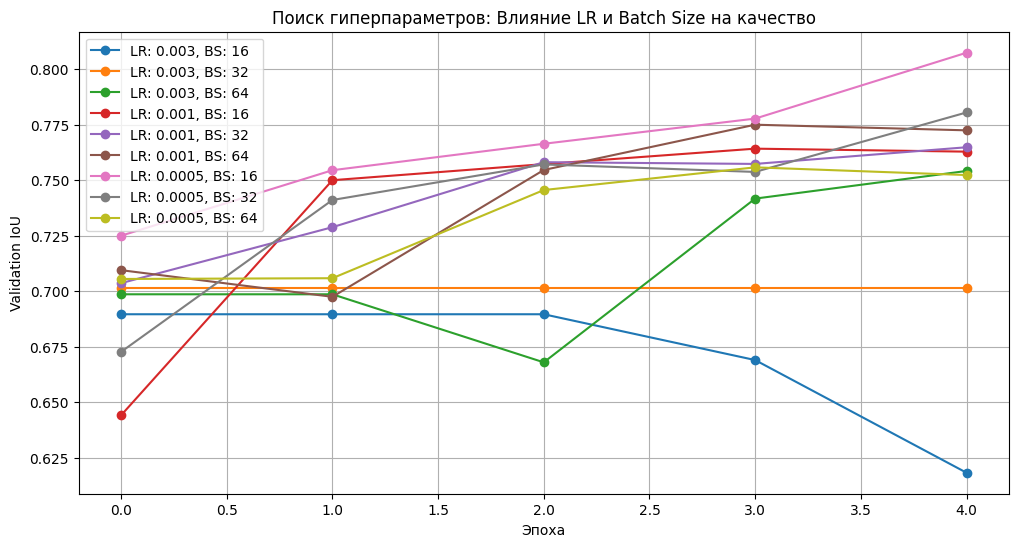

In [15]:
plt.figure(figsize=(12, 6))
for (lr, batch_sz), history in search_results.items():
    plt.plot(history['val_iou'], label=f'LR: {lr}, BS: {batch_sz}', marker='o')

plt.xlabel('Эпоха')
plt.ylabel('Validation IoU')
plt.title('Поиск гиперпараметров: Влияние LR и Batch Size на качество')
plt.legend()
plt.grid(True)
plt.show()

Из графиков видим:

*   Нестабильность высокого LR (0.003), т.к. шаг слишком большой
*   Маленький шаг LR (0.0005) оказался лучше всего, т.к. он позволил лучше настроить фильтр для поиска границ
*    Лучшие результаты у всех моделей показаны при самом маленьком размере батча = 16, т.к. он обеспечил наиболее частые обновления весов

In [21]:
best_learning_rate = 5e-4
best_batch_size = 16
final_epochs = 15

In [22]:
config_final = Config()
config_final.learning_rate = best_learning_rate
config_final.batch_size = best_batch_size
config_final.epochs = final_epochs

In [23]:
trainer_base = Trainer(config_final, use_batchnorm=False)
history_base = trainer_base.run()

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:11<00:00,  3.98it/s]


Epoch 1 / 15, Train Loss: 0.5477, Val Loss: 0.4665, Val IoU: 0.6875, Val F1-score: 0.8093


100%|██████████| 46/46 [00:11<00:00,  4.10it/s]


Epoch 2 / 15, Train Loss: 0.4372, Val Loss: 0.4286, Val IoU: 0.7464, Val F1-score: 0.8486


100%|██████████| 46/46 [00:12<00:00,  3.82it/s]


...

Epoch 14 / 15, Train Loss: 0.1615, Val Loss: 0.2211, Val IoU: 0.8732, Val F1-score: 0.9282


100%|██████████| 46/46 [00:11<00:00,  4.03it/s]


Epoch 15 / 15, Train Loss: 0.1553, Val Loss: 0.2200, Val IoU: 0.8728, Val F1-score: 0.9281
Testing...


100%|██████████| 230/230 [00:58<00:00,  3.95it/s]

Test Loss: 0.2085, Test IoU: 0.8767, Test F1-score: 0.9298


In [24]:
trainer_bn = Trainer(config_final, use_batchnorm=True)
history_bn = trainer_bn.run()

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:11<00:00,  4.15it/s]


Epoch 1 / 15, Train Loss: 0.4394, Val Loss: 0.3750, Val IoU: 0.7762, Val F1-score: 0.8675


100%|██████████| 46/46 [00:11<00:00,  3.92it/s]


Epoch 2 / 15, Train Loss: 0.3435, Val Loss: 0.3720, Val IoU: 0.7795, Val F1-score: 0.8693


100%|██████████| 46/46 [00:11<00:00,  3.99it/s]


...

Epoch 14 / 15, Train Loss: 0.1464, Val Loss: 0.1953, Val IoU: 0.8775, Val F1-score: 0.9309


100%|██████████| 46/46 [00:11<00:00,  3.98it/s]


Epoch 15 / 15, Train Loss: 0.1358, Val Loss: 0.2083, Val IoU: 0.8740, Val F1-score: 0.9291
Testing...


100%|██████████| 230/230 [00:59<00:00,  3.84it/s]

Test Loss: 0.2065, Test IoU: 0.8814, Test F1-score: 0.9331


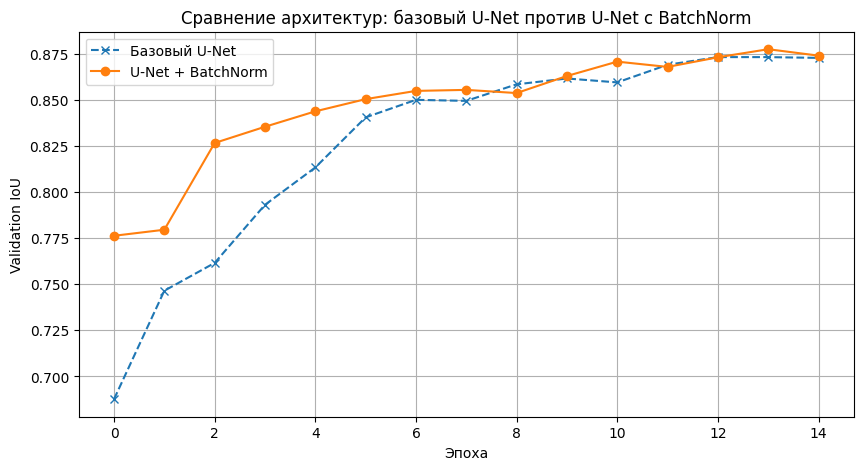

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(history_base['val_iou'], label='Базовый U-Net', marker='x', linestyle='--')
plt.plot(history_bn['val_iou'], label='U-Net + BatchNorm', marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Validation IoU')
plt.title('Сравнение архитектур: базовый U-Net против U-Net c BatchNorm')
plt.legend()
plt.grid(True)
plt.show()


Предсказания лучшей модели (U-Net + BatchNorm):


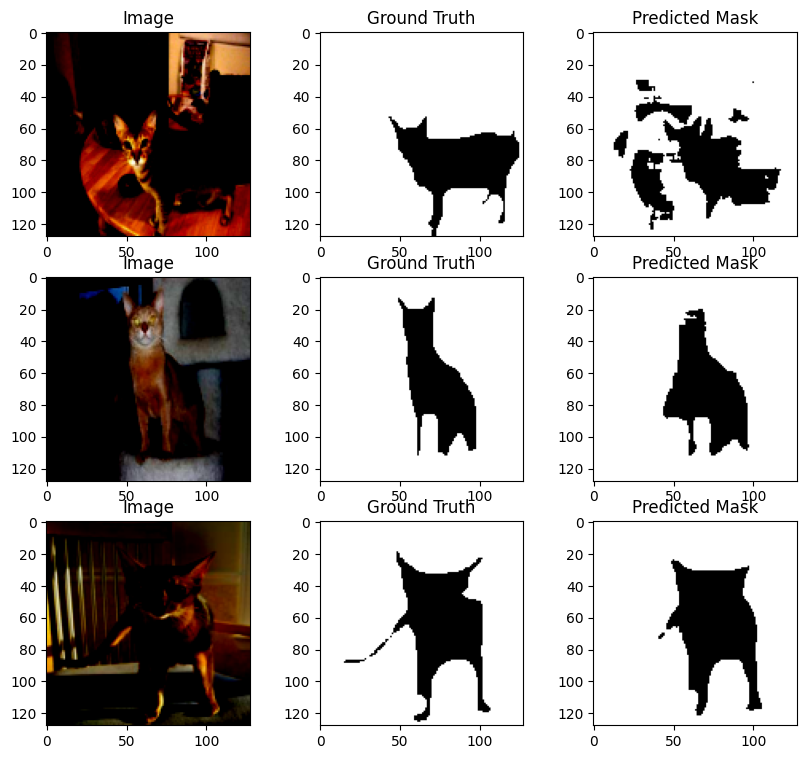

In [26]:
print("\nПредсказания лучшей модели (U-Net + BatchNorm):")
trainer_bn.inference_and_plot_samples(n_samples=3)

**Вывод**

Обучил архитектуру U-Net базовую и с добавлением слоев Batch Normalization

Получился прирост 0.3 в F1 и 0.5 в IoU

Мне кажется это сработало, т.к. Batch Normalization устраняет проблему внутреннего ковариатного сдвига и немного зашумляет данные при расчете статистик батча, что сработало как легкий дропаут